In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Load dataset
df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

# Quick check
print(df.head())
print(df.info())

          Timestamp  Injection_Temperature  Injection_Pressure  Cycle_Time  \
0  01-01-2023 00:00                  221.0               136.0        28.7   
1  01-01-2023 01:00                  213.3               128.9        34.5   
2  01-01-2023 02:00                  222.8               115.9        19.9   
3  01-01-2023 03:00                  233.3               105.3        39.2   
4  01-01-2023 04:00                  212.2               125.5        45.0   

   Cooling_Time  Material_Viscosity  Ambient_Temperature  Machine_Age  \
0          13.6               375.5                 28.0          3.8   
1          14.0               215.8                 22.6          6.8   
2           9.5               307.0                 25.3          4.2   
3          13.1               137.8                 26.0          9.2   
4           9.9               298.2                 23.6          6.2   

   Operator_Experience  Maintenance_Hours    Shift Machine_Type  \
0                 11.2   

In [3]:
# Separate input (X) and output (y)
X = df.drop("Parts_Per_Hour", axis=1)
y = df["Parts_Per_Hour"]

In [4]:
# Convert categorical variables to numeric
X = pd.get_dummies(X)

In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Fill missing values using training data only
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_train.mean(numeric_only=True))

In [7]:
# Scale data (only needed for Linear Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Models used:
# Linear → simple baseline
# Tree → non-linear
# Random Forest → best performance

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [9]:
# Metrics:
# R2 → performance
# MAE → average error
# MSE → large error penalty
# RMSE → real-world error

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse)
    }

In [10]:
results = []

for name, model in models.items():

    # Apply scaling only for Linear Regression
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        train_pred = model.predict(X_train_scaled)
        cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        train_pred = model.predict(X_train)
        cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

    # Store results
    scores = evaluate(y_test, pred)
    scores["Train_R2"] = r2_score(y_train, train_pred)  # check overfitting
    scores["CV_R2"] = cv_score                          # stability
    scores["Model"] = name

    results.append(scores)

In [11]:
# Compare all models
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)

print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

         R2       MAE        MSE      RMSE  Train_R2     CV_R2  \
2  0.856359  3.311670  18.744102  4.329446  0.980829  0.861393   
0  0.798873  4.368938  26.245690  5.123055  1.000000  0.747281   
1  0.738474  4.222500  34.127250  5.841853  1.000000  0.684116   

               Model  
2      Random Forest  
0  Linear Regression  
1      Decision Tree  


In [12]:
# Select model with highest R2
best_model_name = results_df.iloc[0]["Model"]

print("\nBest model selected based on highest R2")
print("Best Model:", best_model_name)


Best model selected based on highest R2
Best Model: Random Forest


In [13]:
best_model = models[best_model_name]

if best_model_name == "Linear Regression":
    best_model.fit(X_train_scaled, y_train)
    final_pred = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    final_pred = best_model.predict(X_test)

In [14]:
# Shows which features affect output most
if best_model_name != "Linear Regression":
    
    importances = best_model.feature_importances_
    
    feat_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nTop Important Features:\n")
    print(feat_df.head())


Top Important Features:

                  Feature  Importance
2              Cycle_Time    0.670250
11       Efficiency_Score    0.079429
7     Operator_Experience    0.050289
10       Total_Cycle_Time    0.044825
0   Injection_Temperature    0.025089


In [15]:
# Final evaluation
print("\nFinal Model Performance:")
print(evaluate(y_test, final_pred))


Final Model Performance:
{'R2': 0.856359164230759, 'MAE': 3.3116700000000003, 'MSE': 18.744101999999998, 'RMSE': 4.329445922979059}


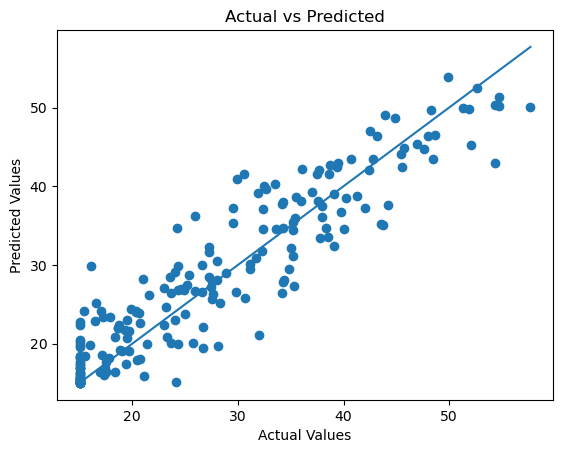

In [16]:
# -------------------- ACTUAL vs PREDICTED --------------------
plt.figure()
plt.scatter(y_test, final_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

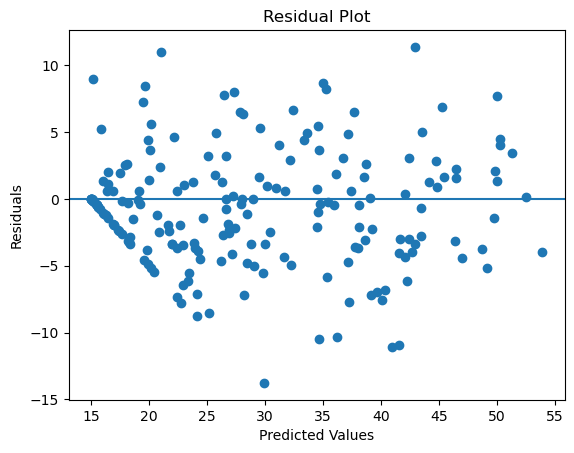

In [17]:
# -------------------- RESIDUAL PLOT --------------------
residuals = y_test - final_pred

plt.figure()
plt.scatter(final_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

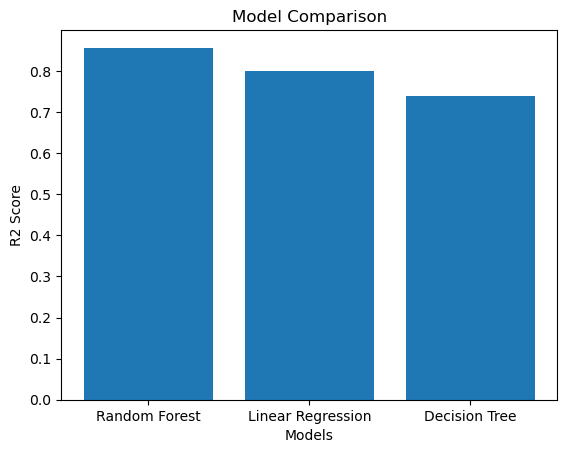

In [18]:
# -------------------- MODEL COMPARISON GRAPH --------------------
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

In [19]:
# Save model for Streamlit
joblib.dump((best_model, scaler), "model.pkl")

print("Model saved successfully!")

Model saved successfully!
